In [57]:
import numpy as np

class perceptron:
    def __init__(self,epochs,lr):
        self.epochs = epochs
        self.lr = lr
        self.W = None

    def fit(self,x_train,y_train):

        y_train = np.array(y_train)
        x_train = np.insert(x_train,0,1,axis=1)
        self.W = np.ones(x_train.shape[1])

        for i in range(self.epochs):
            idx = np.random.randint(0,x_train.shape[0])
            y_hat = np.dot(self.W,x_train[idx])
            if y_hat >=0: y_hat = 1
            else: y_hat = 0 

            self.W = self.W + (self.lr*((y_train[idx]-y_hat)*x_train[idx]))

        return self.W

    def predict(self,x_test):
        x_test = np.insert(x_test,0,1,axis=1)
        y_pred = np.dot(x_test,self.W)
        for i in range(x_test.shape[0]):
            if (y_pred[i] >=0):
                y_pred[i] = 1
            if (y_pred[i] < 0 ):
                y_pred[i] = 0
        return y_pred

In [58]:
import pandas as pd
df = pd.read_csv("C://Users//Acer//OneDrive//Desktop//Datasets//logistic_regression_dataset.csv")
df.drop(columns=['feature_3'],inplace=True)
df.sample(5)

,feature_1,feature_2,target
20,-1.166365,-1.084624,0
11,0.934042,-1.125745,1
9,-2.826435,-0.740383,0
17,-0.244286,-1.159391,1
26,-2.651215,-0.445429,0


In [59]:
x = df.drop(columns=['target'])
y = df['target']

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [60]:
class sigmoid:
    def __init__(self,lr,epochs):
        self.lr = lr
        self.epochs = epochs
        self.W = None

    def fit(self,x_train,y_train):
        y_train = np.array(y_train)
        x_train = np.insert(x_train,0,1,axis=1)
        self.W = np.ones(x_train.shape[1])

        for i in range(self.epochs):
            idx = np.random.randint(0,x_train.shape[0])
            z = np.dot(self.W,x_train[idx])
            y_hat = 1/(1 + np.exp(-z))

            self.W = self.W + (self.lr*(y_train[idx]-y_hat)*x_train[idx])

        return self.W
    
    def predict(self,x_test):
        x_test = np.insert(x_test,0,1,axis=1)
        z =  (np.dot(x_test,self.W))
        y_pred = 1/(1 + np.exp(-z))
        for i in range(x_test.shape[0]):
            y_pred[i]= 1 if y_pred[i] >=0.5 else 0

        return y_pred
        

In [61]:
pr = perceptron(epochs=1000,lr=0.01)
pr.fit(x_train,y_train)

array([0.9       , 1.08734235, 0.82749476])

In [62]:
sg = sigmoid(lr=0.01,epochs=1000)
sg.fit(x_train,y_train)

array([0.94069891, 1.98064228, 1.09556631])

In [63]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
lr.intercept_,lr.coef_

(array([1.19761337]), array([[2.44351223, 1.40617294]]))

In [64]:
from sklearn.metrics import accuracy_score
print(f"Accuracy for perceptron(step-fn) = {accuracy_score(y_test,pr.predict(x_test))}")
print(f"Accuracy for perceptron(sigmoid) = {accuracy_score(y_test,sg.predict(x_test))}")
print(f"Accuracy for LogisticReg(sklearn) = {accuracy_score(y_test,lr.predict(x_test))}")

Accuracy for perceptron(step-fn) = 0.9
Accuracy for perceptron(sigmoid) = 0.9
Accuracy for LogisticReg(sklearn) = 0.9


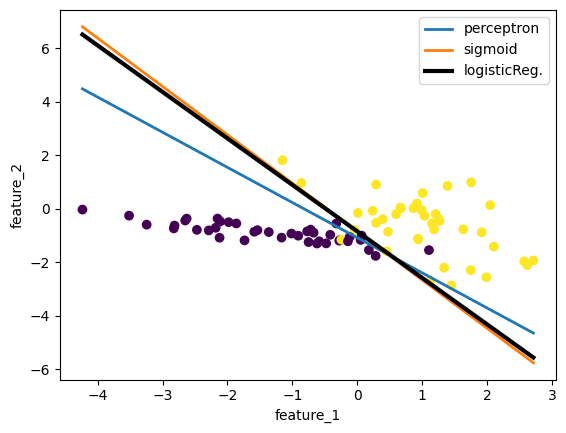

In [65]:
import matplotlib.pyplot as plt
plt.scatter(x_train['feature_1'],x_train['feature_2'],c=y_train)
x_values = np.linspace(x_train['feature_1'].min(),x_train['feature_1'].max(),100)
for i in [pr,sg]:
    w = i.W
    intercept = w[0]
    coef = w[1:]

    y_values = -(coef[0] * x_values + intercept) / coef[1]
    plt.plot(x_values, y_values,label=['perceptron' if i==pr else 'sigmoid'],linewidth=2)

inter = lr.intercept_[0]
coeff = lr.coef_[0]
y_vals = -(coeff[0]*x_values + inter)/coeff[1]
plt.plot(x_values,y_vals,label = 'logisticReg.',c="#000000",linewidth=3)

plt.xlabel('feature_1')
plt.ylabel('feature_2')
plt.legend()
plt.show()
    